In [39]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [40]:
BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "creepypastas.xlsx"

PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_clean.csv"

RAW_DATA_PATH

PosixPath('../data/raw/creepypastas.xlsx')

In [41]:
Path("..")

PosixPath('..')

In [42]:
if RAW_DATA_PATH.exists():
    print("Archivo encontrado correctamente.")
else:
    print("Archivo NO encontrado. Revisa que esté en data/raw/ y que se llame creepypastas.xlsx")

Archivo encontrado correctamente.


In [43]:
excel_file = pd.ExcelFile(RAW_DATA_PATH)

excel_file.sheet_names

['Sheet1']

In [44]:
sheet_name = excel_file.sheet_names[0]

df = pd.read_excel(RAW_DATA_PATH, sheet_name=sheet_name)

df.head()

,story_name,average_rating,tags,body,estimated_reading_time,publish_date,categories
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time\n","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...",12 minutes,"February 20, 2020","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens"
1,A Shattered Life,9.13,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel\n","I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...",14 minutes,"July 22, 2020","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens"
2,My Father Punished Me When I Talked to Ghosts,9.12,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders\n","I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...",8 minutes,"December 10, 2019","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
3,Distorted Warning Signals,9.12,Ashley Rose Wellman\n,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...",3 minutes,"July 13, 2019","Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H..."
4,He Who Wanders,9.12,Simon Simonian\n,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...",22 minutes,"January 24, 2017",Beings and Entities


In [45]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.columns

Filas: 3510
Columnas: 7


Index(['story_name', 'average_rating', 'tags', 'body',
       'estimated_reading_time', 'publish_date', 'categories'],
      dtype='str')

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   story_name              3510 non-null   str    
 1   average_rating          3510 non-null   float64
 2   tags                    2081 non-null   str    
 3   body                    3510 non-null   str    
 4   estimated_reading_time  3509 non-null   str    
 5   publish_date            3510 non-null   str    
 6   categories              3509 non-null   str    
dtypes: float64(1), str(6)
memory usage: 192.1 KB


In [47]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

tags                      1429
categories                   1
estimated_reading_time       1
average_rating               0
story_name                   0
body                         0
publish_date                 0
dtype: int64

In [48]:
duplicate_rows = df.duplicated().sum()

print("Filas duplicadas completas:", duplicate_rows)

Filas duplicadas completas: 0


In [49]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df_clean.columns

Index(['story_name', 'average_rating', 'tags', 'body',
       'estimated_reading_time', 'publish_date', 'categories'],
      dtype='str')

In [50]:
df_clean.head()

,story_name,average_rating,tags,body,estimated_reading_time,publish_date,categories
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time\n","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...",12 minutes,"February 20, 2020","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens"
1,A Shattered Life,9.13,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel\n","I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...",14 minutes,"July 22, 2020","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens"
2,My Father Punished Me When I Talked to Ghosts,9.12,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders\n","I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...",8 minutes,"December 10, 2019","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
3,Distorted Warning Signals,9.12,Ashley Rose Wellman\n,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...",3 minutes,"July 13, 2019","Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H..."
4,He Who Wanders,9.12,Simon Simonian\n,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...",22 minutes,"January 24, 2017",Beings and Entities


In [51]:
possible_title_cols = [col for col in df_clean.columns if "title" in col or "name" in col]
possible_text_cols = [col for col in df_clean.columns if "text" in col or "story" in col or "body" in col or "content" in col]
possible_rating_cols = [col for col in df_clean.columns if "rating" in col or "score" in col or "rate" in col]

print("Posibles columnas de título:", possible_title_cols)
print("Posibles columnas de texto:", possible_text_cols)
print("Posibles columnas de rating:", possible_rating_cols)

Posibles columnas de título: ['story_name']
Posibles columnas de texto: ['story_name', 'body']
Posibles columnas de rating: ['average_rating']


In [52]:
title_col = "story_name"
text_col = "body"
rating_col = "average_rating"

In [53]:
df_project = df_clean[[title_col, text_col, rating_col]].copy()

df_project = df_project.rename(columns={
    title_col: "title",
    text_col: "story_text",
    rating_col: "rating"
})

df_project.head()

,title,story_text,rating
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...",9.25
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...",9.13
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...",9.12
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...",9.12
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...",9.12


In [54]:
df_project = df_project.dropna(subset=["story_text"])

df_project["story_text"] = df_project["story_text"].astype(str)

df_project["story_text"] = df_project["story_text"].str.strip()

df_project = df_project[df_project["story_text"] != ""]

print("Filas después de limpiar textos vacíos:", df_project.shape[0])

Filas después de limpiar textos vacíos: 3510


In [55]:
df_project["title"] = df_project["title"].fillna("Untitled")

df_project["title"] = df_project["title"].astype(str).str.strip()

df_project.head()

,title,story_text,rating
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...",9.25
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...",9.13
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...",9.12
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...",9.12
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...",9.12


In [56]:
df_project["rating_numeric"] = pd.to_numeric(df_project["rating"], errors="coerce")

invalid_ratings = df_project["rating_numeric"].isnull().sum()

print("Ratings inválidos o vacíos:", invalid_ratings)

Ratings inválidos o vacíos: 0


In [57]:
title_col = "story_name"
text_col = "body"
rating_col = "average_rating"

In [58]:
df_project = df_clean[
    [
        "story_name",
        "average_rating",
        "tags",
        "body",
        "estimated_reading_time",
        "publish_date",
        "categories"
    ]
].copy()

df_project = df_project.rename(columns={
    "story_name": "title",
    "average_rating": "rating",
    "body": "story_text"
})

df_project.head()

,title,rating,tags,story_text,estimated_reading_time,publish_date,categories
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time\n","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...",12 minutes,"February 20, 2020","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens"
1,A Shattered Life,9.13,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel\n","I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...",14 minutes,"July 22, 2020","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens"
2,My Father Punished Me When I Talked to Ghosts,9.12,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders\n","I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...",8 minutes,"December 10, 2019","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
3,Distorted Warning Signals,9.12,Ashley Rose Wellman\n,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...",3 minutes,"July 13, 2019","Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H..."
4,He Who Wanders,9.12,Simon Simonian\n,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...",22 minutes,"January 24, 2017",Beings and Entities


In [59]:
print("Rows:", df_project.shape[0])
print("Columns:", df_project.shape[1])

df_project.columns

Rows: 3510
Columns: 7


Index(['title', 'rating', 'tags', 'story_text', 'estimated_reading_time',
       'publish_date', 'categories'],
      dtype='str')

In [60]:
df_project.isnull().sum()

title                        0
rating                       0
tags                      1429
story_text                   0
estimated_reading_time       1
publish_date                 0
categories                   1
dtype: int64

In [61]:
df_project["tags"] = df_project["tags"].fillna("no_tags")
df_project["categories"] = df_project["categories"].fillna("uncategorized")
df_project["estimated_reading_time"] = df_project["estimated_reading_time"].fillna("unknown")

df_project.isnull().sum()

title                     0
rating                    0
tags                      0
story_text                0
estimated_reading_time    0
publish_date              0
categories                0
dtype: int64

In [62]:
df_project["rating"].head(20)

0     9.25
1     9.13
2     9.12
3     9.12
4     9.12
5     9.12
6     9.12
7     9.11
8     9.11
9     9.11
10    9.11
11    9.10
12    9.10
13    9.10
14    9.10
15    9.10
16    9.10
17    9.10
18    9.10
19    9.10
Name: rating, dtype: float64

In [63]:
df_project["rating_numeric"] = pd.to_numeric(df_project["rating"], errors="coerce")

invalid_ratings = df_project["rating_numeric"].isnull().sum()

print("Invalid Ratings or empty:", invalid_ratings)

Invalid Ratings or empty: 0


In [64]:
df_project["rating_numeric"].describe()

count    3510.000000
mean        7.565046
std         1.132757
min         0.860000
25%         6.980000
50%         7.790000
75%         8.420000
max         9.250000
Name: rating_numeric, dtype: float64

In [65]:
df_project["story_length_chars"] = df_project["story_text"].str.len()

df_project["word_count"] = df_project["story_text"].str.split().str.len()

df_project[["title", "rating_numeric", "story_length_chars", "word_count"]].head()

,title,rating_numeric,story_length_chars,word_count
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,19494,3560
1,A Shattered Life,9.13,20840,3919
2,My Father Punished Me When I Talked to Ghosts,9.12,10860,2135
3,Distorted Warning Signals,9.12,4151,768
4,He Who Wanders,9.12,32767,6021


In [72]:
short_stories = df_project[df_project["word_count"] < 50]

print("Stories with less than 50 words:", short_stories.shape[0])

short_stories[["title", "word_count", "story_text"]].head()

Stories with less than 50 words: 0


,title,word_count,story_text


In [67]:
df_project["text_lower"] = df_project["story_text"].str.lower()

df_project[["title", "text_lower"]].head()

,title,text_lower
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu..."
1,A Shattered Life,"i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a ..."
2,My Father Punished Me When I Talked to Ghosts,"i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ..."
3,Distorted Warning Signals,"when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ..."
4,He Who Wanders,"i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ..."


In [68]:
df_project["publish_date"] = pd.to_datetime(df_project["publish_date"], errors="coerce")

df_project[["title", "publish_date"]].head()

,title,publish_date
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",2020-02-20
1,A Shattered Life,2020-07-22
2,My Father Punished Me When I Talked to Ghosts,2019-12-10
3,Distorted Warning Signals,2019-07-13
4,He Who Wanders,2017-01-24


In [69]:
df_project = df_project[
    [
        "title",
        "story_text",
        "text_lower",
        "rating",
        "rating_numeric",
        "story_length_chars",
        "word_count",
        "tags",
        "categories",
        "estimated_reading_time",
        "publish_date"
    ]
]

df_project.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19494,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time\n","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a ...",9.13,9.13,20840,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel\n","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10860,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders\n","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4151,768,Ashley Rose Wellman\n,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H...",3 minutes,2019-07-13
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,9.12,32767,6021,Simon Simonian\n,Beings and Entities,22 minutes,2017-01-24


In [ ]:
print("Last rows:", df_project.shape[0])
print("Final columns:", df_project.shape[1])

df_project.info()

Last rows: 3482
Final cokumns: 11
<class 'pandas.DataFrame'>
Index: 3482 entries, 0 to 3509
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   title                   3482 non-null   str           
 1   story_text              3482 non-null   str           
 2   text_lower              3482 non-null   str           
 3   rating                  3482 non-null   float64       
 4   rating_numeric          3482 non-null   float64       
 5   story_length_chars      3482 non-null   int64         
 6   word_count              3482 non-null   int64         
 7   tags                    3482 non-null   str           
 8   categories              3482 non-null   str           
 9   estimated_reading_time  3482 non-null   str           
 10  publish_date            3482 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(6)
memory usage: 326.4 KB


In [75]:
df_project.isnull().sum()

title                     0
story_text                0
text_lower                0
rating                    0
rating_numeric            0
story_length_chars        0
word_count                0
tags                      0
categories                0
estimated_reading_time    0
publish_date              0
dtype: int64

In [76]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

df_project.to_csv(PROCESSED_DATA_PATH, index=False, encoding="utf-8")

print("Archivo limpio guardado en:")
print(PROCESSED_DATA_PATH)

Archivo limpio guardado en:
../data/processed/creepypastas_clean.csv


In [79]:
df_check = pd.read_csv(PROCESSED_DATA_PATH)

df_check.head()

df_check.info()

<class 'pandas.DataFrame'>
RangeIndex: 3482 entries, 0 to 3481
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   3482 non-null   str    
 1   story_text              3482 non-null   str    
 2   text_lower              3482 non-null   str    
 3   rating                  3482 non-null   float64
 4   rating_numeric          3482 non-null   float64
 5   story_length_chars      3482 non-null   int64  
 6   word_count              3482 non-null   int64  
 7   tags                    3482 non-null   str    
 8   categories              3482 non-null   str    
 9   estimated_reading_time  3482 non-null   str    
 10  publish_date            3482 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 299.4 KB


In [89]:
import matplotlib.pyplot as plt

from collections import Counter

import seaborn as sns

import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [82]:
BASE_DIR = Path("..")
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_clean.csv"

df = pd.read_csv(PROCESSED_DATA_PATH)

df.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19494,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time\n","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a ...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a ...",9.13,9.13,20840,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel\n","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10860,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders\n","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4151,768,Ashley Rose Wellman\n,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H...",3 minutes,2019-07-13
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,9.12,32767,6021,Simon Simonian\n,Beings and Entities,22 minutes,2017-01-24


In [84]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3482
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 3482 entries, 0 to 3481
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   3482 non-null   str    
 1   story_text              3482 non-null   str    
 2   text_lower              3482 non-null   str    
 3   rating                  3482 non-null   float64
 4   rating_numeric          3482 non-null   float64
 5   story_length_chars      3482 non-null   int64  
 6   word_count              3482 non-null   int64  
 7   tags                    3482 non-null   str    
 8   categories              3482 non-null   str    
 9   estimated_reading_time  3482 non-null   str    
 10  publish_date            3482 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 299.4 KB


In [85]:
df[["title", "rating_numeric", "story_length_chars", "word_count"]].head()

,title,rating_numeric,story_length_chars,word_count
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,19494,3560
1,A Shattered Life,9.13,20840,3919
2,My Father Punished Me When I Talked to Ghosts,9.12,10860,2135
3,Distorted Warning Signals,9.12,4151,768
4,He Who Wanders,9.12,32767,6021


In [86]:
df["rating_numeric"].describe()

count    3482.000000
mean        7.566373
std         1.132246
min         0.860000
25%         6.980000
50%         7.790000
75%         8.420000
max         9.250000
Name: rating_numeric, dtype: float64

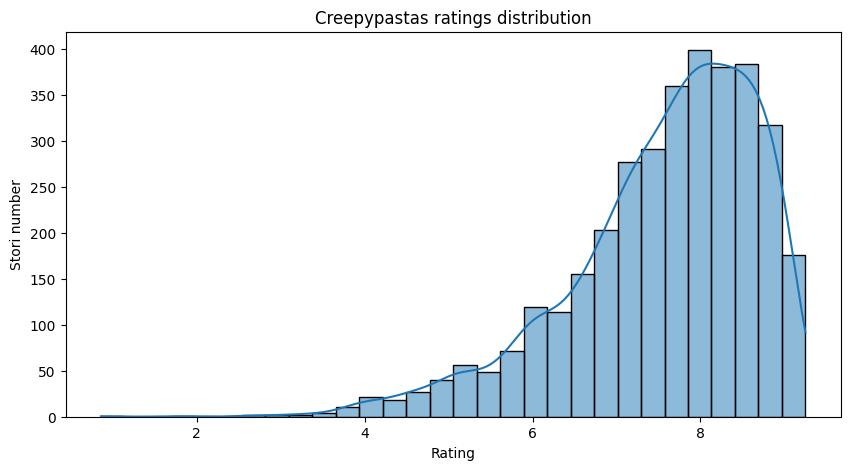

In [90]:
plt.figure(figsize=(10, 5))

sns.histplot(df["rating_numeric"], bins=30, kde=True)

plt.title("Creepypastas ratings distribution")
plt.xlabel("Rating")
plt.ylabel("Stori number")

plt.show()

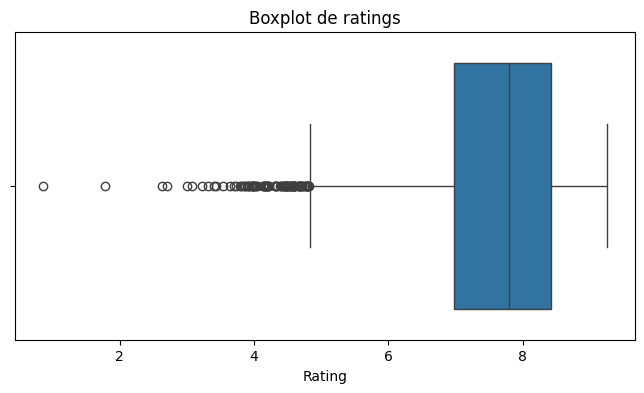

In [91]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["rating_numeric"])

plt.title("Boxplot de ratings")
plt.xlabel("Rating")

plt.show()

In [92]:
df["word_count"].describe()

count    3482.000000
mean     2311.430213
std      1741.343434
min        51.000000
25%       931.500000
50%      1873.500000
75%      3273.500000
max      6566.000000
Name: word_count, dtype: float64

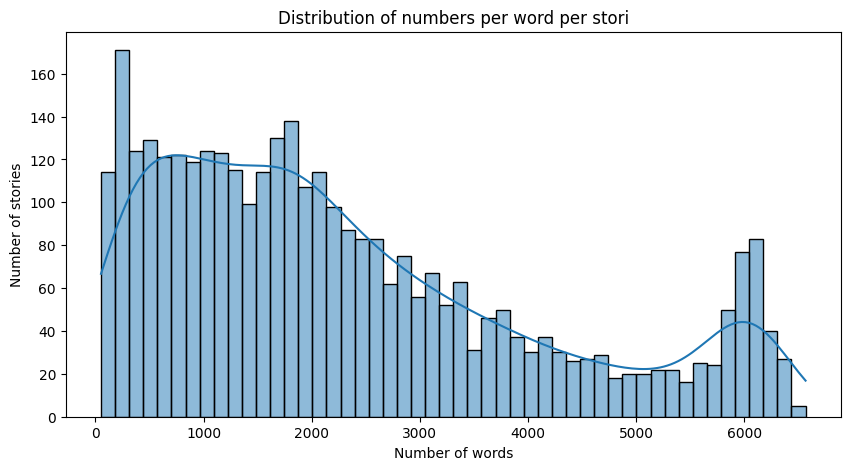

In [103]:
plt.figure(figsize=(10, 5))

sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of numbers per word per stori")
plt.xlabel("Number of words")
plt.ylabel("Number of stories")

plt.show()

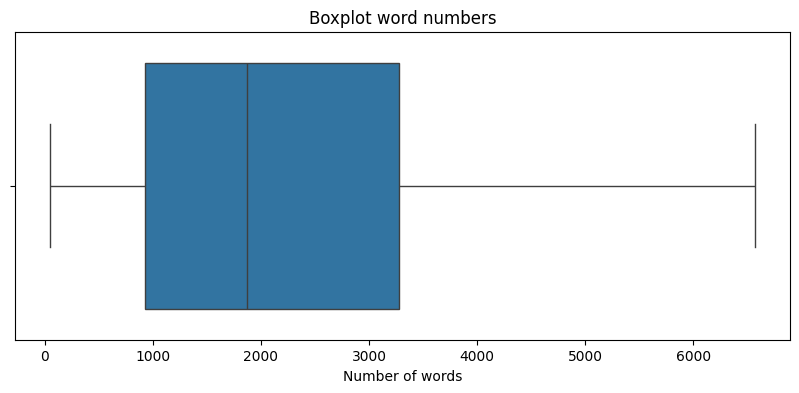

In [102]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["word_count"])

plt.title("Boxplot word numbers")
plt.xlabel("Number of words")

plt.show()

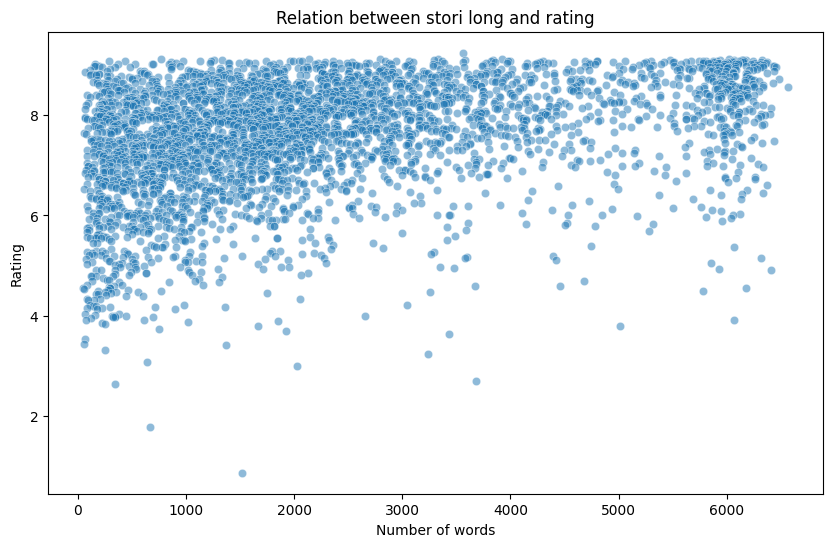

In [101]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="word_count",
    y="rating_numeric",
    alpha=0.5
)

plt.title("Relation between stori long and rating")
plt.xlabel("Number of words")
plt.ylabel("Rating")

plt.show()

In [100]:
correlation = df["word_count"].corr(df["rating_numeric"])

print("Correlation between word_count y rating:", correlation)

Correlation between word_count y rating: 0.346022165557798


In [97]:
top_rated = df.sort_values("rating_numeric", ascending=False).head(10)

top_rated[["title", "rating_numeric", "word_count", "estimated_reading_time", "categories"]]

,title,rating_numeric,word_count,estimated_reading_time,categories
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,3560,12 minutes,"Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens"
1,A Shattered Life,9.13,3919,14 minutes,"Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens"
2,My Father Punished Me When I Talked to Ghosts,9.12,2135,8 minutes,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
3,Distorted Warning Signals,9.12,768,3 minutes,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H..."
4,He Who Wanders,9.12,6021,22 minutes,Beings and Entities
5,The Living History Project,9.12,2798,10 minutes,"Artifacts and Objects, Deaths, Murders, and Disappearances, Historical Fiction, Journals and Diaries, Locations and Sites, Military and Warfare, Strange and Unexplained, Technology, the Internet,..."
6,I Found a Letter From My Stalker,9.12,3326,12 minutes,"Body Horror, Madness, Paranoia, and Mental Illness, Strange and Unexplained"
7,Don’t Let Them In,9.11,3838,13 minutes,"Children and Childhood, Drugs and Addictions, Madness, Paranoia, and Mental Illness, Suspense and Thrillers"
8,What Happens When the Stars Go Out,9.11,6142,21 minutes,"Deaths, Murders, and Disappearances, Feelspastas and Happy Endings, Hell and the Afterlife, Strange and Unexplained"
9,The Seer of Possibilities,9.11,5476,19 minutes,Beings and Entities


In [98]:
longest_stories = df.sort_values("word_count", ascending=False).head(10)

longest_stories[["title", "rating_numeric", "word_count", "estimated_reading_time", "categories"]]

,title,rating_numeric,word_count,estimated_reading_time,categories
675,The Pixies,8.57,6566,34 minutes,"Beings and Entities, Folklore and Folktales, Myths and Legends"
454,The Wormhole,8.72,6479,26 minutes,"Beings and Entities, Science Fiction and Aliens, Strange and Unexplained"
187,Strange Things Happen Overnight at Lowe’s,8.96,6459,52 minutes,"Jobs and Occupations, Strange and Unexplained"
171,From Me to You,8.98,6440,41 minutes,"Madness, Paranoia, and Mental Illness\nPlease wait...\n"
2094,The Fog Has Eyes,7.49,6438,55 minutes,"Monsters, Creatures, and Cryptids"
256,The Serial Killer Showdown,8.89,6435,39 minutes,"Deaths, Murders, and Disappearances"
555,NoEnd House,8.65,6426,48 minutes,"Beings and Entities, Famous Creepypasta, Locations and Sites, Madness, Paranoia, and Mental Illness, Psychological Horror, Strange and Unexplained, Survival Horror, Suspense and Thrillers"
157,Miss Fortune,8.99,6425,38 minutes,Beings and Entities
3375,The Woods Past Dark,4.90,6407,40 minutes,Strange and Unexplained\n
1255,Death Dreams,8.14,6405,43 minutes,"Madness, Paranoia, and Mental Illness"


In [99]:
short_high_rated = (
    df[df["word_count"] < df["word_count"].median()]
    .sort_values("rating_numeric", ascending=False)
    .head(10)
)

short_high_rated[["title", "rating_numeric", "word_count", "categories"]]

,title,rating_numeric,word_count,categories
3,Distorted Warning Signals,9.12,768,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival H..."
12,Mommy Sleeps in the Basement,9.10,1255,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
14,The Well,9.10,1329,"Based on True Events, Beings and Entities, Historical Fiction"
35,Mr. Widemouth,9.09,1740,"Beings and Entities, Children and Childhood, Famous Creepypasta, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Strange and Unexplained"
37,The Gift Of Mercy,9.09,1232,"Deaths, Murders, and Disappearances, Science Fiction and Aliens, Space and Cosmic Horror"
49,Sadie,9.08,288,"Deaths, Murders, and Disappearances, Famous Creepypasta, Illness and Injuries, Madness, Paranoia, and Mental Illness, Sounds and Voices, Strange and Unexplained, Urban Legends, Video Games and Ga..."
54,Lightning,9.08,437,Strange and Unexplained
55,An Egg,9.08,974,Strange and Unexplained\n
56,Survival Guide,9.08,1131,"Dark Comedy, Humor, and Parodies, Rites and Rituals"
70,Ickbarr Bigelsteine,9.07,1552,"Artifacts and Objects, Beings and Entities, Children and Childhood, Famous Creepypasta, Feelspastas and Happy Endings, Monsters, Creatures, and Cryptids, Toys and Dolls"


In [104]:
df["categories"].value_counts().head(20)

categories
Beings and Entities\n                                         298
Strange and Unexplained\n                                     273
Beings and Entities                                           249
Strange and Unexplained                                       240
Madness, Paranoia, and Mental Illness\n                       128
Deaths, Murders, and Disappearances\n                         127
Deaths, Murders, and Disappearances                            97
Locations and Sites\n                                          69
Locations and Sites                                            63
Madness, Paranoia, and Mental Illness                          62
Rites and Rituals                                              48
Artifacts and Objects\n                                        46
Rites and Rituals\n                                            45
Based on True Events, Beings and Entities                      43
Beings and Entities, Strange and Unexplained\n                 35

In [105]:
category_rating = (
    df.groupby("categories")["rating_numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

category_rating.head(20)

,count,mean
categories,,
"Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",1,9.25
"Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",1,9.13
"Artifacts and Objects, Deaths, Murders, and Disappearances, Historical Fiction, Journals and Diaries, Locations and Sites, Military and Warfare, Strange and Unexplained, Technology, the Internet, and the Deep Web",1,9.12
"Body Horror, Madness, Paranoia, and Mental Illness, Strange and Unexplained",1,9.12
"Children and Childhood, Drugs and Addictions, Madness, Paranoia, and Mental Illness, Suspense and Thrillers",1,9.11
"Deaths, Murders, and Disappearances, Feelspastas and Happy Endings, Hell and the Afterlife, Strange and Unexplained",1,9.11
"Beings and Entities, Conspiracies and Government, Famous Creepypasta, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation",1,9.11
"Children and Childhood, Deaths, Murders, and Disappearances, Journals and Diaries, Monsters, Creatures, and Cryptids, Myths and Legends, Nature and the Outdoors",1,9.10
"Artifacts and Objects, Deaths, Murders, and Disappearances, Demons and Possession, Madness, Paranoia, and Mental Illness, Occult, Magic, and Witchcraft, Slashers and Gore",1,9.10


In [106]:
all_text = " ".join(df["text_lower"].dropna().astype(str))

all_text[:500]

'if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance through my brain before it hits my hippocampus. if i’m lucky, the sensation of the gunshot ripping through my skull will only last a few decades.\n\nas awful as this sounds, you’ll be doing me an enormous favor. death by a headshot, as soon as possible, is vastly better than the alternative.\nmy ordeal started o'

In [107]:
clean_text = re.sub(r"[^a-zA-Z\s]", " ", all_text)

words = clean_text.split()

len(words)

8213984

In [108]:
stopwords = {
    "the", "and", "to", "of", "a", "i", "in", "it", "that", "was",
    "my", "he", "she", "you", "we", "they", "his", "her", "for",
    "on", "with", "as", "had", "but", "at", "me", "is", "be",
    "this", "not", "have", "from", "or", "so", "if", "when",
    "there", "were", "all", "one", "what", "by", "an", "would",
    "could", "then", "out", "up", "said", "just", "like", "about"
}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

len(filtered_words)

4348543

In [109]:
word_counts = Counter(filtered_words)

top_words = word_counts.most_common(30)

top_words

[('him', 26900),
 ('into', 25787),
 ('back', 24268),
 ('been', 19081),
 ('down', 18809),
 ('time', 18253),
 ('them', 17032),
 ('didn', 15821),
 ('over', 15797),
 ('see', 15397),
 ('more', 15293),
 ('before', 15217),
 ('eyes', 15099),
 ('now', 15002),
 ('only', 14819),
 ('your', 14571),
 ('some', 14519),
 ('something', 14512),
 ('door', 14435),
 ('around', 14251),
 ('can', 14143),
 ('know', 14054),
 ('even', 14017),
 ('their', 13437),
 ('after', 13428),
 ('through', 13343),
 ('room', 13253),
 ('are', 13139),
 ('get', 13006),
 ('still', 12582)]

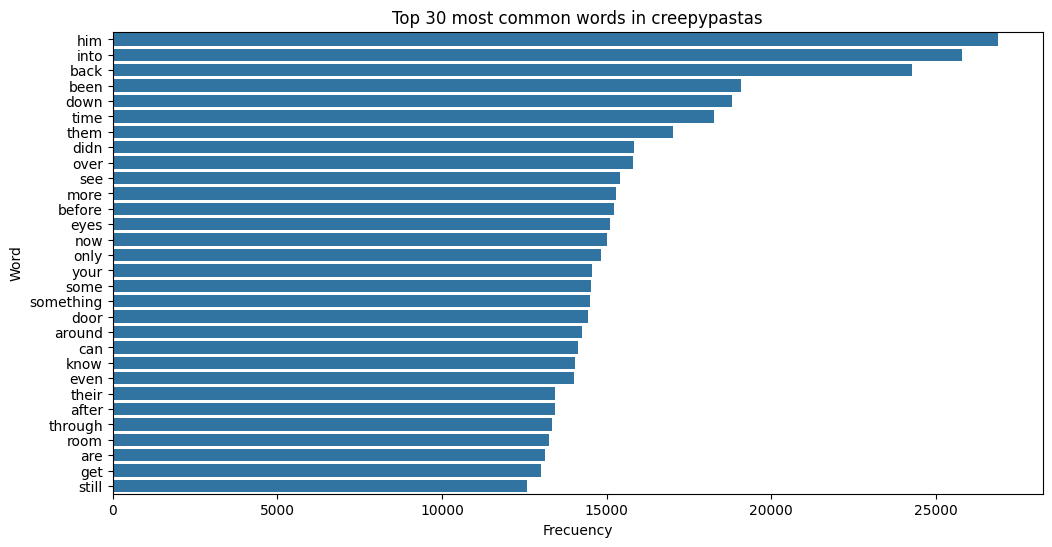

In [110]:
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words_df,
    x="count",
    y="word"
)

plt.title("Top 30 most common words in creepypastas")
plt.xlabel("Frecuency")
plt.ylabel("Word")

plt.show()

In [111]:
EDA_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_eda_ready.csv"

df.to_csv(EDA_DATA_PATH, index=False, encoding="utf-8")

print("File saved in:")
print(EDA_DATA_PATH)

File saved in:
../data/processed/creepypastas_eda_ready.csv
